# Session 4 — Demo 2 — Two cases, one ambush

**What this demo covers.** Two live hypotheses on the warehouse:

1. **Shelf levels** — does floor and ladder territory slow picking down? (t-test vs Mann–Whitney, plus a confounder check.)
2. **SmallParts items** — do they get confused more often? This is where the *obvious* metric lies to us first.

Plus the AI moment: how to ask "which test?" so the answer fits your data.

**How we work tonight.** ❓ question → 🔍 what we'll do (hidden: think first) → ✅ what it means → ⛔ what it does NOT mean.

> 🖼 **Card 4** in `concept-cards.html` (same folder) is the picture for the second case: what a wrong scan actually records. Keep it closed until we get there. It is the answer to a puzzle.

**Data.** The ALPHA week — [data dictionary](../../data/README.md).

**How to run.** Locally: top to bottom. Colab: uncomment the lines in the setup cell. Needs `scipy`.

## 0. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator

# where the data lives, relative to this notebook
DATA = Path("../../data/alpha")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/alpha")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib seaborn scipy

In [2]:
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid.

    minor="x", "y" or "xy" also adds small ticks between the labelled ones.
    """
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)

---

## 1. The table for tonight: one row per pick

Demo 1 worked with whole tasks and `picks_per_hour`. Both hypotheses tonight are about *single picks*: a shelf level and an item belong to one pick, not to a task. So we need a different number: the **seconds one pick took**, counted from the previous event of the same task.

Two things about that number, said once so they do not trip you later.

- It is a **different quantity** from `picks_per_hour`, not a rewriting of it. Picks per hour describes a whole task and bigger is faster. Seconds per pick describes one pick and **smaller is faster**. Check the direction before you read any chart below.
- The recipe is session 3's window function, unchanged: sort inside the task, then `.diff()`. Session 3 ran it over *every* event and called the result `gap_seconds` (median 7.2 s). Tonight we keep only the successful picks, so the same column comes out with a different median. Same trick, different population.

In [3]:
events = pd.read_parquet(DATA / "picking_events.parquet")
topology = pd.read_parquet(DATA / "topology.parquet")
ovh = pd.read_parquet(DATA / "ovh.parquet")
item_tags = pd.read_parquet(DATA / "item_tags.parquet")

events_by_task_time = events.sort_values(["task_id", "event_time"]).copy()
events_by_task_time["pick_seconds"] = (
    events_by_task_time
    .groupby("task_id")["event_time"]   # gaps inside one task only
    .diff()                             # each row minus the one above
    .dt.total_seconds()
)
events_by_task_time[["task_id", "event_type", "event_time", "pick_seconds"]].head(4)

,task_id,event_type,event_time,pick_seconds
0,800000001,StartTask,2026-03-02 11:51:59.142,NaN
1,800000001,ScanCell,2026-03-02 11:53:33.779,94.637
2,800000001,PickWrongItem,2026-03-02 11:53:47.415,13.636
3,800000001,PickCorrectItem,2026-03-02 11:53:56.955,9.540


Now keep only the rows that mean "an item was successfully picked, and we know how long it took":

In [4]:
timed_picks = events_by_task_time[
    (events_by_task_time["event_type"] == "PickCorrectItem")
    & events_by_task_time["pick_seconds"].notna()   # first event of a task: no gap
    & (events_by_task_time["pick_seconds"] > 0)     # same-second events: no signal
]
print(
    f"all events: {len(events_by_task_time):,}\n"
    f"picks with a measurable time: {len(timed_picks):,}"
)

all events: 311,543
picks with a measurable time: 145,904


Two joins bring in what the hypotheses are about: the **shelf level** of the cell (topology) and the **weight** of the item (the OVH table). Session 2's habit applies: count the rows before and after, because a join is the quietest way to lose or duplicate data:

In [5]:
rows_before_joins = len(timed_picks)

timed_picks = timed_picks.merge(
    topology[["cell_id", "cell_level_in_rack"]],
    on="cell_id",
    how="inner",
)
timed_picks = timed_picks.merge(
    ovh[["item_id", "weight"]],
    on="item_id",
    how="inner",
)

print(f"rows before the joins: {rows_before_joins:,}   after: {len(timed_picks):,}")
assert len(timed_picks) == rows_before_joins, "a join dropped or multiplied rows"

rows before the joins: 145,904   after: 145,904


---

## 2. ❓ Case 1 — "does the shelf level change picking speed?"

**Hypothesis, written before looking:** level 1 means bending down, levels 5–6 mean fetching a ladder, and both should be slower than the comfortable middle at chest height.

**What would change my mind:** a flat profile across levels, or a profile explained by something else that lives on the low shelves (heavy items, for instance).

<details>
<summary>🔍 <b>What we'll do</b> — how would you check this? Think first, then open</summary>

Median seconds per pick at each shelf level, as bars from zero. Median, not mean: session 3 showed how a few long pauses drag the mean of these times. And remember the direction here: a **taller** bar is a **slower** level.
</details>

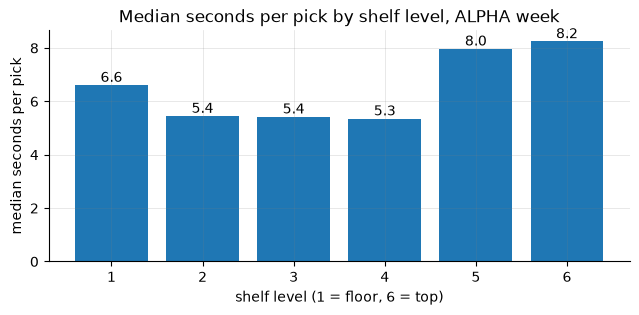

picks per level:
cell_level_in_rack
1    32163
2    30119
3    26280
4    21144
5    18931
6    17267
Name: count, dtype: int64


In [6]:
median_pick_seconds_by_level = (
    timed_picks
    .groupby("cell_level_in_rack")["pick_seconds"]
    .median()
)

fig, ax = plt.subplots(figsize=(7.5, 3))

level_bars = ax.bar(
    median_pick_seconds_by_level.index,
    median_pick_seconds_by_level.to_numpy(),
    color="tab:blue",
)
ax.bar_label(level_bars, fmt="%.1f")
ax.set_title("Median seconds per pick by shelf level, ALPHA week")
ax.set_xlabel("shelf level (1 = floor, 6 = top)")
ax.set_ylabel("median seconds per pick")
make_ax_better(ax)

plt.show()

print("picks per level:")
# .sort_index() orders the result by level 1..6 instead of by frequency
print(timed_picks["cell_level_in_rack"].value_counts().sort_index())

There is the U-shape the hypothesis predicted: about 6.6 s at the floor, 5.4 s in the comfort zone, 8 s up the ladder. Taller bar, slower level.

But six medians are six numbers, and we now know better than to trust a gap on sight. Two groups → **draw the shapes**, not just the summary (session 3's rule). We take the floor against the comfortable middle, level 1 against level 3, because those are the two the hypothesis is actually about.

One argument in the next cell is doing real work. Level 1 has 32,163 picks and level 3 has 26,280, so plain counts would make the blue hill taller for a reason that has nothing to do with speed. `stat="percent"` puts both groups on their own scale — the habit from session 3's two-warehouse histogram.

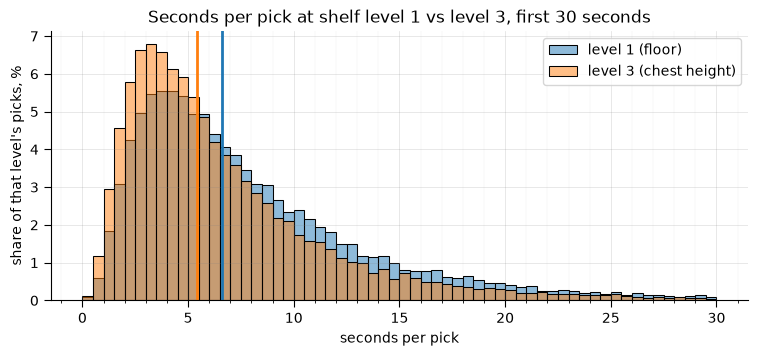

picks outside the 0-30 s window: 1,914 of 58,443 = 3.3%   longest: 1,513 s


In [7]:
level1_pick_seconds = timed_picks.loc[
    timed_picks["cell_level_in_rack"] == 1, "pick_seconds"
]
level3_pick_seconds = timed_picks.loc[
    timed_picks["cell_level_in_rack"] == 3, "pick_seconds"
]

fig, ax = plt.subplots(figsize=(9, 3.5))

sns.histplot(
    level1_pick_seconds,
    bins=60,
    binrange=(0, 30),
    stat="percent",
    color="tab:blue",
    alpha=0.5,
    label="level 1 (floor)",
    ax=ax,
)
sns.histplot(
    level3_pick_seconds,
    bins=60,
    binrange=(0, 30),
    stat="percent",
    color="tab:orange",
    alpha=0.5,
    label="level 3 (chest height)",
    ax=ax,
)
ax.axvline(level1_pick_seconds.median(), color="tab:blue", lw=2)
ax.axvline(level3_pick_seconds.median(), color="tab:orange", lw=2)
ax.set_title("Seconds per pick at shelf level 1 vs level 3, first 30 seconds")
ax.set_xlabel("seconds per pick")
ax.set_ylabel("share of that level's picks, %")
ax.legend()
make_ax_better(ax, minor="x")

plt.show()

level1_and_3 = pd.concat([level1_pick_seconds, level3_pick_seconds])
hidden_picks = level1_and_3[level1_and_3 > 30]
print(
    f"picks outside the 0-30 s window: {len(hidden_picks):,} of "
    f"{len(level1_and_3):,} = {len(hidden_picks) / len(level1_and_3):.1%}   "
    f"longest: {level1_and_3.max():,.0f} s"
)

The blue hump sits to the right of the orange one, which means slower, and both have the long right tail we already know. Two things follow from this picture, and they matter for the next cell:

- the groups **do** look shifted, so the comparison is worth a test;
- the tail is enormous. A pick that takes twenty-five minutes is rare, but it counts as 250 ordinary picks when you take an average.

So we run **two** tests here. Our default, `stats.ttest_ind`, compares the **means**. And because of that tail we also ask for a second opinion, `stats.mannwhitneyu`, which compares the **ranks** and cannot be pulled around by a single huge value. Both take the two groups and return a result object with `.pvalue` inside.

**The rule from demo 1, because you will need it in a second:** a minus in the exponent moves the dot **left**, so the bigger the number after `e-`, the smaller the p-value. `1e-195` is vastly smaller than `1e-14`, not bigger.

In [8]:
from scipy import stats

# equal_var=False every time: Welch's version of the same test
level_ttest = stats.ttest_ind(
    level1_pick_seconds,
    level3_pick_seconds,
    equal_var=False,
)
level_mannwhitney = stats.mannwhitneyu(level1_pick_seconds, level3_pick_seconds)

print(
    f"level 1 vs level 3, n = {len(level1_pick_seconds):,} / "
    f"{len(level3_pick_seconds):,}\n"
    f"median  {level1_pick_seconds.median():.2f} s vs "
    f"{level3_pick_seconds.median():.2f} s\n"
    f"mean    {level1_pick_seconds.mean():.2f} s vs "
    f"{level3_pick_seconds.mean():.2f} s\n"
    f"t-test        p = {level_ttest.pvalue:.2e}\n"
    f"Mann-Whitney  p = {level_mannwhitney.pvalue:.2e}"
)

level 1 vs level 3, n = 32,163 / 26,280
median  6.61 s vs 5.42 s
mean    11.09 s vs 9.25 s
t-test        p = 1.49e-14
Mann-Whitney  p = 1.56e-195


✅ **What it means:** the default test answers first. **t-test p = 1.5e-14**, so the two levels differ in mean pick time and luck is not a candidate explanation. The second opinion agrees and then some: Mann-Whitney says `1e-195`, which by the rule from demo 1 is the far smaller number.

Why do two tests on the same data land a hundred and eighty orders of magnitude apart? Because they summarise the column differently, and here the two summaries are far apart. The **mean** pick at level 1 takes 11.1 s. The **typical** pick takes 6.6 s. A handful of twenty-five-minute pauses do that. The t-test makes a statement about 11.1 s; the rank test makes one about the everyday pick.

Neither is wrong, and here they agree, so report both numbers. That is rule 4 of tonight's checklist: **the effect is 6.6 s against 5.4 s at the median, 11.1 s against 9.2 s at the mean, and both tests say it is not luck.**

⛔ **What it does NOT mean:** that the effect is huge because the p-value is tiny. About a second and two tenths per pick is worth money only when multiplied by 32,000 picks. And it does not mean bending is the *cause* yet. That is the next cell.

### ❓ The discipline beat: what ELSE differs between these groups?

<details>
<summary>🔍 <b>What we'll do</b> — name a rival explanation, then test it</summary>

The floor is where warehouses like to put heavy things. If heavy items live on level 1, we may be measuring **weight**, not posture. So: median weight per level, and then the same comparison on light items only. If bending is real, the effect survives inside the light-items-only world.
</details>

**Where to cut "light", and why it is a decision.** We use `weight < 0.5` kg, which is the 75th percentile of the column, so three quarters of picks stay in. That keeps the light-items group big enough to test and still throws out every genuinely heavy item. A cut at the median would be defensible too, and a cut at 2 kg would leave almost nothing out and prove nothing. **Say where you cut and why** — HW1 Part 2 gives marks for exactly that sentence, and takes them away when the number appears from nowhere.

In [9]:
median_weight_by_level = (
    timed_picks
    .groupby("cell_level_in_rack")["weight"]
    .median()
    .round(2)
)
median_weight_by_level

cell_level_in_rack
1    0.22
2    0.25
3    0.20
4    0.23
5    0.20
6    0.21
Name: weight, dtype: float64

In [10]:
light_item_picks = timed_picks[timed_picks["weight"] < 0.5]

light_level1_pick_seconds = light_item_picks.loc[
    light_item_picks["cell_level_in_rack"] == 1, "pick_seconds"
]
light_level3_pick_seconds = light_item_picks.loc[
    light_item_picks["cell_level_in_rack"] == 3, "pick_seconds"
]
light_ttest = stats.ttest_ind(
    light_level1_pick_seconds,
    light_level3_pick_seconds,
    equal_var=False,
)
light_mannwhitney = stats.mannwhitneyu(
    light_level1_pick_seconds,
    light_level3_pick_seconds,
)

print(
    f"the cut keeps {(timed_picks['weight'] < 0.5).mean():.1%} of all picks\n"
    f"light items only (< 0.5 kg), n = {len(light_level1_pick_seconds):,} / "
    f"{len(light_level3_pick_seconds):,}\n"
    f"median  {light_level1_pick_seconds.median():.2f} s vs "
    f"{light_level3_pick_seconds.median():.2f} s\n"
    f"mean    {light_level1_pick_seconds.mean():.2f} s vs "
    f"{light_level3_pick_seconds.mean():.2f} s\n"
    f"t-test p = {light_ttest.pvalue:.1e}   "
    f"Mann-Whitney p = {light_mannwhitney.pvalue:.1e}"
)

the cut keeps 72.8% of all picks
light items only (< 0.5 kg), n = 23,260 / 19,872
median  6.50 s vs 5.36 s
mean    11.11 s vs 9.08 s
t-test p = 6.6e-13   Mann-Whitney p = 1.6e-143


✅ **What it means:** median weights are nearly flat across levels (0.20–0.25 kg), and among light items alone the effect survives almost untouched, on both summaries and under both tests. Weight is not the explanation; bending down really does cost about a second. That check is what separates analysis from anecdote, **and one sentence of exactly this shape is what "research logic" means in the HW1 rubric.**

⛔ **What it does NOT mean:** that we have ruled out *every* rival explanation. We tested one, the obvious one. Which items live low, which zones have level-1 cells, who picks them: all still open. "I checked the most plausible confounder and it did not explain the effect" is an honest sentence. "There are no confounders" is not.

---

## 3. The AI moment — "am I using the right test?"

**The lazy way:**

> which test to compare two groups?

…returns "use a t-test", with no idea what your column looks like. It happens to be the right starting point, which is worse than being wrong: you get the correct answer for no reason, and you learn nothing about when it stops being correct.

**The useful way — let your data make the choice:**

> You are a statistician. I compare picking times (seconds per pick) between shelf level 1 and level 3: right-skewed, heavy-tailed (medians 6.6 vs 5.4 s, mean 11.1 vs 9.2 s, p99 ≈ 90 s), independent observations, n ≈ 32,000 / 26,000. I plan to use a two-sample t-test. Tell me whether that is safe at this sample size, what exactly it would be a statement about, and what second opinion is worth running beside it.

The answer is the useful one: at n ≈ 30,000 the t-test is on safe ground, it is a statement about the **mean**, and with a tail like this the mean is not the typical pick, so run a rank test alongside and report both. Exactly what we just did. **The assistant is useful when your context makes the choice for it.** Same loop as always: think → ask well → verify. And we verified: both tests agree here.

---

## 4. ❓ Case 2 — "do SmallParts items get confused more often?"

**Hypothesis, from the process, not from the data:** items tagged *SmallParts* are tiny and light, many of them share a single cell, and their packaging barely differs, so the hand should reach for the neighbour more often.

**What would change my mind:** an equal or lower wrong-scan rate on small parts once the metric counts the right thing.

The tag lives in `item_tags`, where each item carries a *list* of tags:

In [11]:
item_tags.head(3)

,item_id,tags
0,318455877,[]
1,913398911,[SmallParts]
2,555848141,[]


A list inside a cell is session 2's `explode` situation: one row per (item, tag) pair, and then the ids we want are a simple filter away.

In [12]:
tags_long = item_tags.explode("tags")
small_parts_item_ids = tags_long.loc[tags_long["tags"] == "SmallParts", "item_id"]

print(
    f"items in the catalogue: {len(item_tags):,}   "
    f"tagged SmallParts: {len(small_parts_item_ids):,}"
)

items in the catalogue: 60,000   tagged SmallParts: 4,257


<details>
<summary>🔍 <b>What we'll do</b> — how would YOU measure "gets confused more often"? Think before opening</summary>

The obvious metric: take every pick attempt (a `PickCorrectItem` or a `PickWrongItem` row), split them by whether the **scanned item** is a small part, and compare the share of wrong scans. One `groupby`, one mean of a True/False column.
</details>

In [13]:
scan_attempts = events[
    events["event_type"].isin(["PickCorrectItem", "PickWrongItem"])
]
scan_attempts = scan_attempts.dropna(subset=["item_id"]).copy()
scan_attempts["scanned_small_parts"] = (
    scan_attempts["item_id"].isin(small_parts_item_ids)
)
scan_attempts["is_wrong_scan"] = scan_attempts["event_type"] == "PickWrongItem"

naive_wrong_share = (
    scan_attempts
    .groupby("scanned_small_parts")["is_wrong_scan"]
    .mean()
)
print(
    f"scans used: {len(scan_attempts):,}\n"
    f"wrong-scan share, plain items: {naive_wrong_share[False]:.3f}\n"
    f"wrong-scan share, small parts: {naive_wrong_share[True]:.3f}\n"
    f"ratio: {naive_wrong_share[True] / naive_wrong_share[False]:.2f}"
)

scans used: 172,016
wrong-scan share, plain items: 0.152
wrong-scan share, small parts: 0.145
ratio: 0.95


**Ratio 0.95. Small parts fail *less*.** The hypothesis looks dead, the process story looks like folklore, and if this were a homework we could write "no support for the hypothesis" and go home.

Don't. Replay what session 2 found when it chased the empty `item_id`. What does a `PickWrongItem` row actually record?

> 🖼 Open **card 4** now.

**It records the item you grabbed by mistake: the neighbour on the shelf, not the item you were hunting.** Our metric read the tag of the *wrong* item. When someone hunting a small part grabs the fat box next to it, the row is filed under "plain item". The metric measured which items get *grabbed by accident*, and called it "which items get confused".

There is a second, quieter leak in that cell: `dropna(subset=["item_id"])`. A wrong scan whose barcode never resolved has no `item_id` at all. Those are the 7,205 rows session 2 met in the `groupby` trap, and the naive metric silently threw away every one of them.

So we rebuild the metric around the **cell visit**: all the scans one worker made at one cell inside one task. The item that was *hunted* there is the one the successful pick reveals; every wrong scan in that visit is a confusion while hunting it.

In [14]:
scans_per_visit = events[
    events["event_type"].isin(["PickCorrectItem", "PickWrongItem"])
].copy()

# three True/False columns - the whole fix lives in the third one
scans_per_visit["is_wrong_scan"] = scans_per_visit["event_type"] == "PickWrongItem"
scans_per_visit["is_correct_pick"] = (
    scans_per_visit["event_type"] == "PickCorrectItem"
)
scans_per_visit["picked_small_parts"] = (
    scans_per_visit["is_correct_pick"]
    & scans_per_visit["item_id"].isin(small_parts_item_ids)
)
scans_per_visit[
    ["task_id", "cell_id", "event_type", "item_id", "picked_small_parts"]
].head(4)

,task_id,cell_id,event_type,item_id,picked_small_parts
2,800000001,54400900.0,PickWrongItem,3.014677e+09,False
3,800000001,54400900.0,PickCorrectItem,1.679524e+09,False
5,800000001,43583220.0,PickCorrectItem,1.430083e+09,False
7,800000001,100180332.0,PickCorrectItem,1.965323e+09,False


**Look at the `item_id` column in that output.** It prints as `3.014677e+09`: a decimal point and an exponent, where an id should be a whole number. Session 1 gave us the rule for exactly this, and demo 1 leaned on it an hour ago: **a float id means hidden nulls.** pandas cannot keep whole numbers in a column that has empty cells, so it quietly turns the whole column into decimals.

Which cells are empty? These 179,221 scan rows carry 7,205 of them, every one a `PickWrongItem`. The same 7,205 the naive metric dropped. **The evidence for the ambush was printed on screen before we explained it**, in the shape of a decimal point, and nobody looks at dtypes.

Now group by the visit: `task_id` **and** `cell_id` together. Two familiar tricks do all the work: summing a True/False column counts the `True`s, and taking its maximum answers "did any row in this group say True?".

In [15]:
visits = (
    scans_per_visit
    .groupby(["task_id", "cell_id"])
    .agg(
        wrong_scans=("is_wrong_scan", "sum"),
        correct_picks=("is_correct_pick", "sum"),
        hunts_small_parts=("picked_small_parts", "max"),
    )
)
print(f"cell visits: {len(visits):,}")
visits.head(4)

cell visits: 116,690


wrong_scans  correct_picks  hunts_small_parts
task_id   cell_id                                                  
800000001 43583220.0            0              1              False
          45240204.0            0              1              False
          54400900.0            1              1              False
          83364492.0            0              1              False

One filter, said out loud: a visit with **no** successful pick never reveals what was hunted there, so it cannot be classified and we drop it.

In [16]:
visits_without_a_pick = (visits["correct_picks"] == 0).sum()
print(f"visits with no successful pick (dropped): {visits_without_a_pick}")

visits = visits[visits["correct_picks"] > 0]

scans_by_visit_kind = (
    visits
    .groupby("hunts_small_parts")[["wrong_scans", "correct_picks"]]
    .sum()
)
scans_by_visit_kind["wrong_share"] = (
    scans_by_visit_kind["wrong_scans"]
    / (scans_by_visit_kind["wrong_scans"] + scans_by_visit_kind["correct_picks"])
)
scans_by_visit_kind.round(3)

visits with no successful pick (dropped): 129


,wrong_scans,correct_picks,wrong_share
hunts_small_parts,,,
False,29295,135647,0.178
True,3777,10257,0.269


In [17]:
plain_share = scans_by_visit_kind.loc[False, "wrong_share"]
small_parts_share = scans_by_visit_kind.loc[True, "wrong_share"]
print(
    f"wrong-scan share per visit, plain: {plain_share:.3f}   "
    f"small parts: {small_parts_share:.3f}   "
    f"ratio: {small_parts_share / plain_share:.2f}"
)

# the check that says the rebuilt metric did not invent anything:
# put both kinds of visit back together and we should land on the
# warehouse-wide wrong-scan share session 3 put on the scoreboard
all_wrong_scans = scans_by_visit_kind["wrong_scans"].sum()
all_correct_picks = scans_by_visit_kind["correct_picks"].sum()
print(
    f"both kinds together: "
    f"{all_wrong_scans / (all_wrong_scans + all_correct_picks):.3f}"
)

wrong-scan share per visit, plain: 0.178   small parts: 0.269   ratio: 1.52
both kinds together: 0.185


17.8% against 26.9%, and the effect flipped from ×0.95 to ×1.5 without a single new row of data.

The last line of that cell is the check that keeps us honest. Put both kinds of visit back together and the wrong-scan share is **0.185** — session 3's scoreboard number for ALPHA (18.6%) back again, short only by the 129 pickless visits we dropped. The rebuilt metric splits the same errors differently; it does not invent any. The naive version could not pass this check, because it had already thrown 7,205 of them away.

Is ×1.5 luck? This time we are not comparing distributions of numbers, we are comparing **shares of yes/no counts**, so the test changes with the data (card 3): shares → **chi-square**.

**`stats.chi2_contingency(table)`** answers a question with a slightly different shape from the ones we have asked so far. Not "do these two groups have different averages", but **"are these two things related at all?"** Here: is *what kind of cell visit it was* related to *whether the scan went wrong*?

It wants a **contingency table**: raw counts, one row per group, one column per outcome. Counts, never percentages, because the test needs to know how much evidence stands behind each share. Ten wrong out of a hundred and ten thousand out of a hundred thousand are the same percentage and wildly different evidence.

You rarely type such a table by hand. From raw rows, `pd.crosstab` builds it for you, and we will use it on the real data in a moment.

Start with a toy where the answer is obvious. Two versions of a picking screen, a hundred scans each:

In [18]:
toy_scans = [
    [20, 80],    # screen A: 20 wrong, 80 correct
    [35, 65],    # screen B: 35 wrong, 65 correct
]

toy_result = stats.chi2_contingency(toy_scans)

print(
    f"chi-square statistic: {toy_result.statistic:.2f}\n"
    f"p-value:              {toy_result.pvalue:.3f}\n"
    f"degrees of freedom:   {toy_result.dof}"
)
print("\nexpected counts if the screen made no difference at all:")
print(toy_result.expected_freq.round(1))

chi-square statistic: 4.92
p-value:              0.027
degrees of freedom:   1

expected counts if the screen made no difference at all:
[[27.5 72.5]
 [27.5 72.5]]


Four things come back, and the useful one is the last. **`expected_freq` is the table you would have seen if the two things were unrelated** — the null hypothesis, written out as counts.

Where does 27.5 come from? Pool the groups and forget the labels. Across both screens there were 20 + 35 = 55 wrong scans out of 200, so the shared wrong rate is 55 / 200 = **27.5%**. Apply that rate to each screen's hundred scans and you expect 27.5 wrong and 72.5 correct in both. That is all the null hypothesis says.

Then the statistic measures how far reality sits from that table, cell by cell:

In [19]:
wrong_1, correct_1 = toy_scans[0]
wrong_2, correct_2 = toy_scans[1]

all_scans = wrong_1 + correct_1 + wrong_2 + correct_2
pooled_wrong_share = (wrong_1 + wrong_2) / all_scans

expected_wrong_1 = (wrong_1 + correct_1) * pooled_wrong_share
expected_correct_1 = (wrong_1 + correct_1) * (1 - pooled_wrong_share)
expected_wrong_2 = (wrong_2 + correct_2) * pooled_wrong_share
expected_correct_2 = (wrong_2 + correct_2) * (1 - pooled_wrong_share)

# one term per cell: how far off, squared, divided by what we expected
chi_square_by_hand = (
    (wrong_1 - expected_wrong_1) ** 2 / expected_wrong_1
    + (correct_1 - expected_correct_1) ** 2 / expected_correct_1
    + (wrong_2 - expected_wrong_2) ** 2 / expected_wrong_2
    + (correct_2 - expected_correct_2) ** 2 / expected_correct_2
)

print(
    f"pooled wrong rate:  {pooled_wrong_share:.3f}\n"
    f"chi-square by hand: {chi_square_by_hand:.2f}\n"
    f"scipy agrees:       "
    f"{stats.chi2_contingency(toy_scans, correction=False).statistic:.2f}"
)

pooled wrong rate:  0.275
chi-square by hand: 5.64
scipy agrees:       5.64


Dividing by the expectation is what makes the number fair: being seven counts off matters far more when you expected 27 than when you expected 167.

That statistic is the whole test. The p-value is then one lookup: *how often would pure chance push this sum above 5.64, if the two things really were unrelated?* Not often, so p lands near 0.03, and the screen and the wrong scans look related.

Two more toys to calibrate what "not often" means, and they are the ones to remember:

In [20]:
toy_equal_rates = [
    [10, 90],     # group 1: 10 wrong, 90 correct -> 10%
    [20, 180],    # group 2: 20 wrong, 180 correct -> also 10%
]
toy_double_rate = [
    [10, 90],     # 10%
    [40, 160],    # 20% - twice the rate, on the same tiny sample
]
print(
    f"identical rates -> p = {stats.chi2_contingency(toy_equal_rates).pvalue:.2f}\n"
    f"doubled rate    -> p = {stats.chi2_contingency(toy_double_rate).pvalue:.3f}"
)

identical rates -> p = 1.00
doubled rate    -> p = 0.043


Identical rates give p = 1.00, because reality *is* the expected table. Doubling the rate on three hundred observations barely scrapes under 0.05. **Remember that second number:** the same doubling on a bigger sample will look unarguable, and that is the trap waiting in demo 3.

One honest footnote. On a 2x2 table scipy nudges the statistic down a little by default (Yates's correction), which is why `toy_double_rate` printed 0.043 where the raw sum gives 0.028. It is a small conservative habit, it applies only to 2x2 tables, and on our real table the p-value is so small that nothing about it changes.

**And how do you get a contingency table from raw rows?** You almost never type one by hand. `pd.crosstab` counts the combinations for you, and it is the one line that turns a log into something a test will accept. Seven rows, countable by eye:

In [21]:
toy_rows = pd.DataFrame({
    "screen": ["A", "A", "A", "B", "B", "B", "B"],
    "went_wrong": [True, False, False, True, True, False, True],
})

# crosstab counts the combinations: one row per screen, one column per outcome
pd.crosstab(toy_rows["screen"], toy_rows["went_wrong"])

went_wrong,False,True
screen,,
A,2,1
B,1,3


Two screens, two outcomes, counts in the middle. That is a contingency table, and `chi2_contingency` will take it as it stands.

Our real table is the one we already built by hand, the two count columns per kind of visit. This time we print the expected counts next to the observed ones, because that pair is what makes the verdict readable:

In [22]:
small_parts_chi_square = stats.chi2_contingency(
    scans_by_visit_kind[["wrong_scans", "correct_picks"]]
)

print("observed:")
print(scans_by_visit_kind[["wrong_scans", "correct_picks"]].to_string())
print("\nexpected if hunting a small part made no difference:")
print(small_parts_chi_square.expected_freq.round(0))
print(f"\nchi-square p = {small_parts_chi_square.pvalue:.1e}")

observed:
                   wrong_scans  correct_picks
hunts_small_parts                            
False                    29295         135647
True                      3777          10257

expected if hunting a small part made no difference:
[[ 30479. 134463.]
 [  2593.  11441.]]

chi-square p = 2.7e-158


✅ **What it means:** read the two tables against each other. If hunting a small part made no difference, those visits would have produced about **2,593** wrong scans. They produced **3,777**. That is **1.5× the wrong-scan rate**, and luck is not a candidate explanation (p ≈ 1e-158). The effect was in the data all along; the metric had to understand the process to see it. This is the most transferable lesson of the course: **no statistical test rescues a metric built on a misunderstood process.** The naive number was not "insignificant". It was *wrong*, significantly.

⛔ **What it does NOT mean:** that small parts are hard to *pick*. The per-visit metric counts confusions while hunting an item that shares a cell with lookalike neighbours, so it mixes the item's own properties with how it is stored. Splitting those two would need a different comparison (same items, different cell densities), and that is a fine hypothesis for HW1.

---

## Try it yourself

1. **Oversized** tag → seconds per pick: hypothesis first, then Mann–Whitney. (This one has no ambush. Or does it? State why.)
2. Does the SmallParts ×1.5 hold **in each zone separately**? (Same visit metric, grouped by zone.)
3. Stretch: your own hypothesis from HW1 Part 2, rehearsed here on the shared week.

In [23]:
# your turn

## Recap

- **Seconds per pick is a different quantity from `picks_per_hour`**, not a rewriting of it: smaller is faster. Name the unit before you read a chart.
- **`ttest_ind(a, b, equal_var=False)` is the default**; on a column with a long tail, run `mannwhitneyu` next to it. Both are one-liners, **choosing what to report** is the skill.
- They can differ wildly in decimals because they summarise the column differently: mean 11.1 s against typical 6.6 s. When they agree, say so and report both effect sizes.
- A minus in the exponent moves the dot left: the bigger the number after `e-`, the smaller the p-value.
- Before believing an effect, ask what **else** differs between the groups, and **say where you cut** when you check it.
- An AI is useful when your prompt carries the shape, the sizes and the goal of your data.
- The SmallParts ambush: a wrong scan records the *neighbour*, so the obvious metric inverted the effect; per visit it is ×1.5 at p ≈ 1e-158.
- A rebuilt metric should still add back up to the number you already trust (0.185, session 3's scoreboard).
- **Chi-square** asks whether two things are related. Feed it raw counts (`pd.crosstab` builds the table), and read `expected_freq` next to what you observed: 3,777 wrong scans where 2,593 were expected.
- **Metric before test. Process before metric.**

> 🖼 **After class, if you want the other half of the story:** **card 2** in `concept-cards.html` builds the p-value the way a statistics course does, through samples, the central limit theorem, confidence intervals and the bootstrap. Two of its panels have sliders. **Card 5** is the fuller test-choosing map, paired data included.